#**1. 결정트리**
- sklearn 패키지의 iris 데이터셋 이용
- Iris 데이터는 붓꽃의 꽃받침/꽃잎 길이와 너비를 기반으로
3가지 품종을 분류하는 대표적인 분류 데이터셋이다.
- train_test_split을 통해 학습용과 테스트용 데이터를 분리한다.

##**1) Iris 데이터를 로딩하고, 훈련세트와 테스트 세트로 나누기(훈련 세트 : 80%, random_state=423)**

In [2]:
## 데이터 준비
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

# 데이터 훈련/테스트 세트로 분할 (80:20 비율, random_state=423)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 423)

##**2) DecisionTreeClassifier로  모델 학습하기**

In [3]:
from sklearn.tree import DecisionTreeClassifier

# 모델 생성 및 학습
dt_clf = DecisionTreeClassifier(random_state = 423)
dt_clf.fit(
    X_train, y_train
    )

DecisionTreeClassifier(random_state=423)

♦️ 노드 정보 설명

- feature <= threshold : 데이터를 나누는 기준
- gini : 노드의 불순도 (0에 가까울수록 순수)
- samples : 해당 노드에 포함된 데이터 수
- value : 각 클래스별 데이터 개수
    예: [40, 5, 0] → 첫 번째 클래스가 대부분

##**3) export_graphviz로 트리 시각화하기**

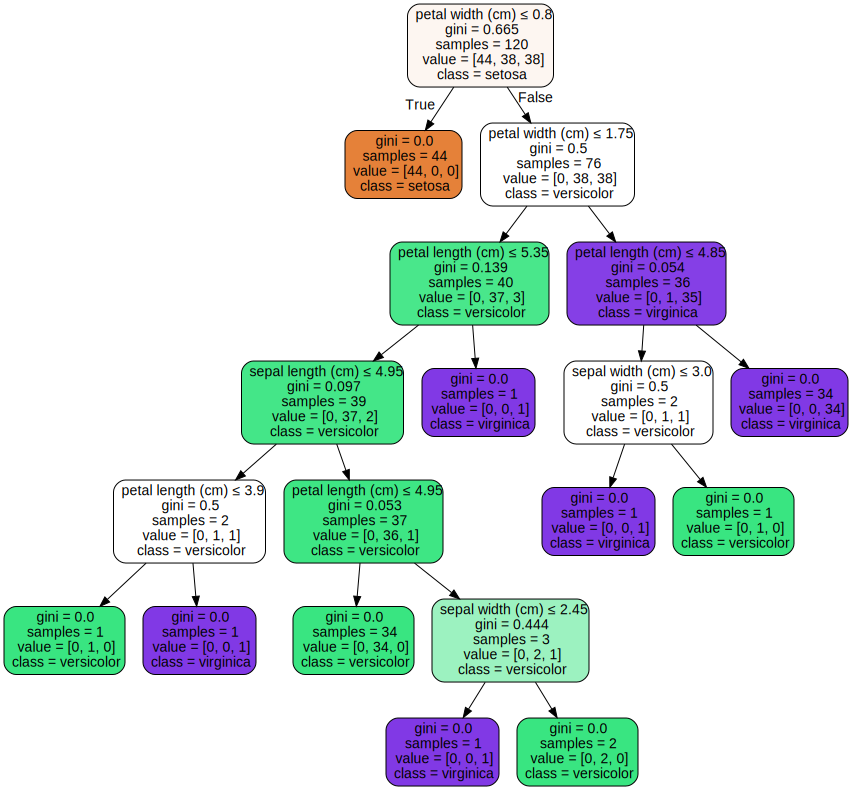

In [6]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_clf,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

##**4) 테스트 데이터로 예측 정확도 구하기**

In [7]:
from sklearn.metrics import accuracy_score

# 테스트 세트에 대한 예측 수행
pred = dt_clf.predict(X_test)
accuracy= accuracy_score(y_test,pred)

print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))

결정 트리 예측 정확도 : 0.9667


##**5) GridSearchCV를 이용한 하이퍼파라미터 튜닝하기**

In [8]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=423)

grid = GridSearchCV(dt, params, cv=3)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_
      )
print("최고 정확도:", grid.best_score_
      )

최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
최고 정확도: 0.9499999999999998


##**6) 최적 모델 평가하기**

In [9]:
best_dt_clf = grid.best_estimator_

pred = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("최종 정확도:", accuracy)

최종 정확도: 0.9333333333333333


##**7) Feature Importance 시각화**

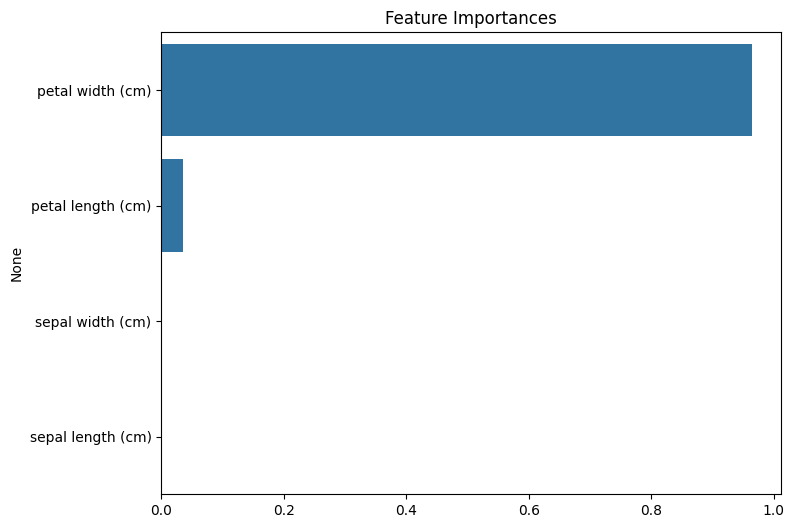

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 최적의 모델에서 피처 중요도 추출
ftr_importances_values = best_dt_clf.feature_importances_

# Series로 변환
ftr_importances = pd.Series(
    ftr_importances_values,
    index=iris.feature_names
    )

# 중요도 순으로 정렬
ftr_top = ftr_importances.sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8,6))
plt.title('Feature Importances')

sns.barplot(
    x=ftr_top.values,
    y=ftr_top.index,
    )

plt.show()

1. 'wine' 데이터셋을 불러온 후 훈련/테스트 세트를 분리해주세요.

In [14]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 데이터 로드
wine = load_wine()
X_features = wine.data
y_label = wine.target

# 훈련/테스트 세트 분리 (비율이 적혀있지 않아 80:20으로 설정)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=423)

2. 로지스틱 회귀와 KNN을 개별 모델로 선언한 후 하드 보팅 방식으로 결합해주세요.

로지스틱 회귀: solver='liblinear'로 설정

KNN: n_neighbors=10로 설정

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

#로지스틱 회귀와 KNN을 개별 모델로 선언
Ir_clf = LogisticRegression(solver = 'liblinear')
knn_clf = KNeighborsClassifier(n_neighbors = 10)

#하드 보팅 방식의 분류기 선언
vo_clf = VotingClassifier(estimators=[('LR', Ir_clf), ('KNN', knn_clf)], voting='hard')

3-1. 앞서 선언한 로지스틱 회귀와 KNN 모델을 리스트에 담아 for문으로 학습 및 예측해주세요.

3-2. 각 모델의 정확도를 출력해주세요.

In [18]:
from sklearn.metrics import accuracy_score

#개별 모델의 학습/예측/평가
models = [Ir_clf, knn_clf]

for model in models :
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    class_name = model.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))


LogisticRegression 정확도: 0.9444
KNeighborsClassifier 정확도: 0.5278


4. 2번에서 생성한 보팅 분류기를 학습시킨 후 예측 평가해주세요.

In [19]:
# 보팅 분류기 학습 및 예측
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('보팅 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

보팅 분류기 정확도: 0.5833


5. 결정 트리를 기반으로 하는 배깅 분류기를 생성하고 학습시켜 주세요.

결정 트리 분류기: 600개

무작위 선택 샘플 수: 80개

중복 샘플링 허용, 모든 코어 사용

In [20]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 배깅 분류기 생성 (600개 트리, 80개 샘플, 중복 허용, 모든 코어 사용)
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=600,
    max_samples=80,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True
)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=80,
                  n_estimators=600, n_jobs=-1, oob_score=True)

6. obb 평가를 수행하고 점수를 확인해 주세요.

In [22]:
# oob_score 확인
print("obb 점수:", bag_clf.oob_score_)

obb 점수: 0.9647887323943662


7. 학습된 배깅 분류기를 이용해 테스트 데이터에 대한 예측을 수행하고 정확도를 평가해 주세요.

In [23]:
from sklearn.metrics import accuracy_score

pred = bag_clf.predict(X_test)
print("배깅 분류기 최종 정확도:", accuracy_score(y_test, pred))

배깅 분류기 최종 정확도: 0.9444444444444444


# 4-4. Randomforest

- 다음은 classification에 관한 문제이다. 이용하는 데이터의 이름은 “classification_data”이다. 데이터의 dimension은 (4521, 17)으로 이는 4521개의 observation이있으며 1개의 target column과 16개의 feature column으로 구성되었음을 의미한다. 이 데이터는 bank diposit에 관한 데이터로 보증금 대출가능 여부에 대한 정보를 담고 있다. Target column은 y이며 보증금 대출이 가능한 경우 “yes”, 불가능한 경우 “no”로 표기되어 있다.

- random seed 설정에 유의할 것.

(a) 데이터를 불러온 후 처음 4줄을 출력하시오.

In [9]:
import pandas as pd

df = pd.read_csv('/content/classification_data.csv',sep=';')

df.head(4)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no


(b) 필요한 변수에 대하여 one-hot encoding과 label encoding을 하시오.



hint)

 label encoding : 'default', 'housing', 'loan', 'y'

 one-hot encoding : 'job', 'marital', 'education', 'contact','month', 'poutcome'

In [10]:
from sklearn.preprocessing import LabelEncoder

#레이블 인코딩 수행
le = LabelEncoder()
label_cols = ['default', 'housing', 'loan', 'y']
for col in label_cols:
    df[col] = le.fit_transform(df[col])

#원 핫 인코딩 수행
onehot_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=onehot_cols)

(c) Data를 X(feature), y(target)으로 분리하시오.

In [11]:
X = df.drop('y', axis=1)
y = df['y']

(d) Data를 train/test로 split 하시오. (train:test = 3:1, random_seed = 777)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777)

(e) Random Forest에 대하여 model fitting 하시오.

    - max_depth = 3, n_estimators = 200, learning_rate = 0.1, random_state = 777

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf = RandomForestClassifier(n_estimators = 200, max_depth = 3, random_state = 777)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=200, random_state=777)

(f) (e)의 결과에 대하여 confution matrix를 구하시오.

In [15]:
from sklearn.metrics import confusion_matrix

print(f"Random Forest의 confution matrix: \n {confusion_matrix(y_test, rf_clf.predict(X_test))}")

Random Forest의 confution matrix: 
 [[1014    0]
 [ 117    0]]


# 서포트 벡터 머신(SVM)

가우시안 RBF 커널을 사용하여 gamma 값이 2이고, 하이퍼파라미터 C의 값이 0.005인 SVM 분류기를 만드시오.

In [16]:
from sklearn.svm import SVC

# 가우시안 RBF 커널, gamma=2, C=0.005 설정
svm_clf = SVC(kernel='rbf', gamma=2, C=0.005)
svm_clf.fit(X_train, y_train)

SVC(C=0.005, gamma=2)